# Loss hyperparam impact


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_hyper_vs_metric(df, metric='HYBRID_SCORE'):
    # Combine hyperparameters + metric into a DataFrame
    cols = ['link','entropy','reconstruction','contrastive','balance','repel', metric]
    data = df[cols].dropna()

    # Rename for prettier axis labels if needed
    rename_map = {
        'link': 'Link KW',
        'entropy': 'Entropy',
        'reconstruction': 'Recon',
        'contrastive': 'Contrast',
        'balance': 'Balance',
        'repel': 'Repel',
        metric: metric.replace('_', ' ').title()
    }
    data = data.rename(columns=rename_map)

    # Create a pairplot
    sns.set(style="ticks")
    grid = sns.pairplot(
        data,
        x_vars=list(rename_map.values())[:-1],
        y_vars=[rename_map[metric]],
        kind='scatter',
        height=3, aspect=1,
        plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'}
    )

    # Optionally add regression lines to each subplot
    for ax in grid.axes.flatten():
        x_label = ax.get_xlabel()
        if x_label:  # avoid empty plots
            sns.regplot(
                data=data,
                x=x_label, y=rename_map[metric],
                scatter=False, ax=ax,
                line_kws={'color': 'red', 'lw': 1}
            )

    plt.tight_layout()
    plt.show()



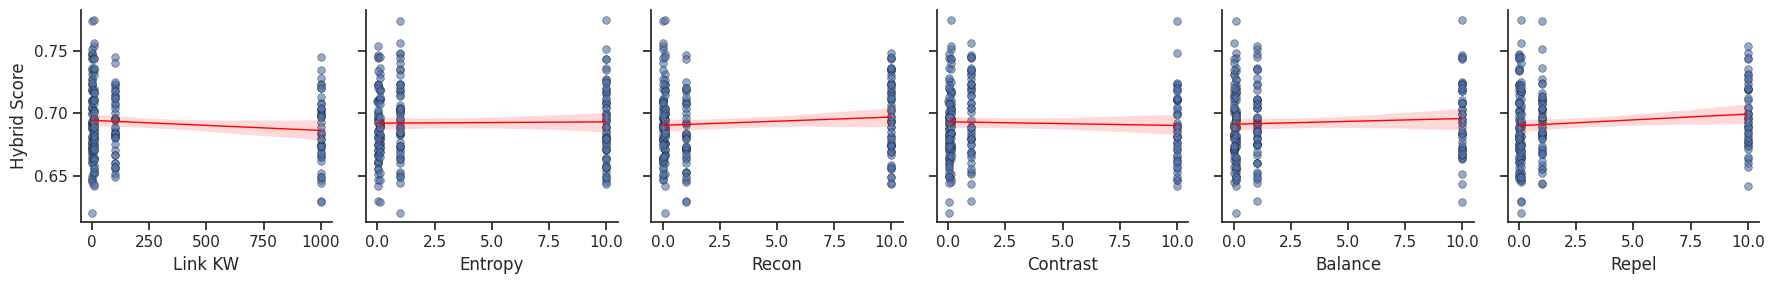

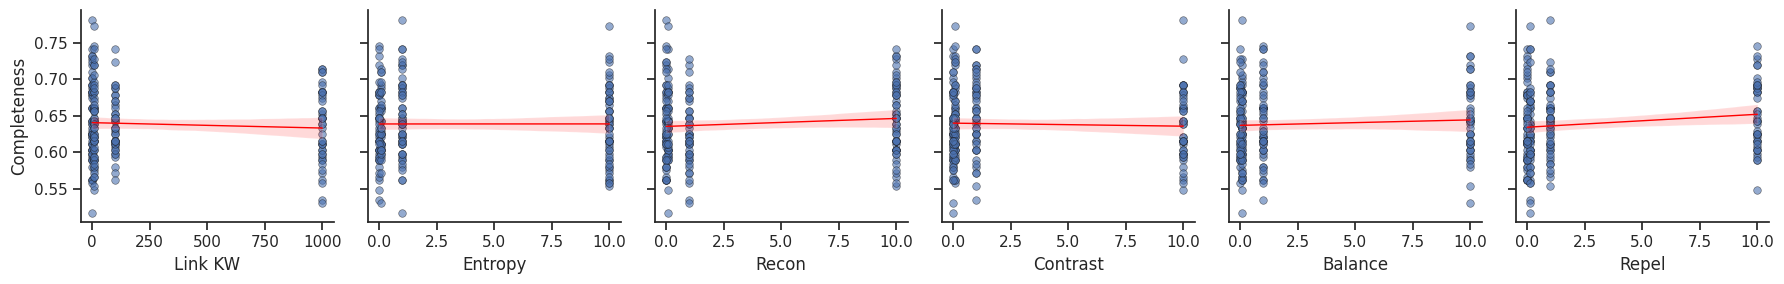

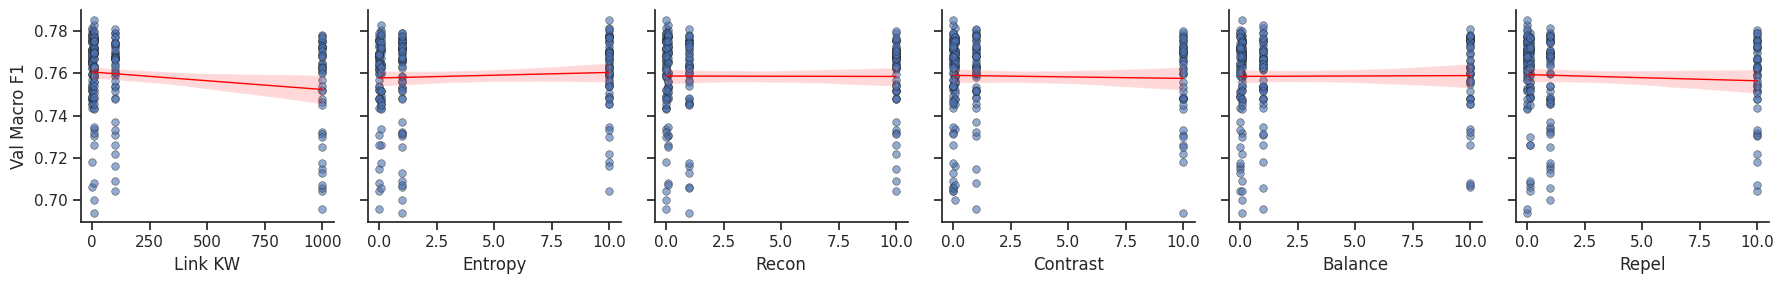

In [3]:
# To use:
df = pd.read_excel("../gridsearch_results_IMDB_loss.xlsx")
plot_hyper_vs_metric(df, metric='HYBRID_SCORE')
plot_hyper_vs_metric(df, metric='COMPLETENESS')
plot_hyper_vs_metric(df, metric='VAL_MACRO_F1')
# or switch to 'VAL_MACRO_F1', 'COMPLETENESS'


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_violin_hyperparams(df, hyperparams, metric='HYBRID_SCORE'):
    """
    Plots up to two violin plots side by side (in one row).
    - df: Pandas DataFrame with your data.
    - hyperparams: list of 1 or 2 column names to treat as categorical on x-axis.
                   They will be binned (e.g., quartiles) to visualize distributions.
    - metric: continuous metric column to plot on y-axis.
    """
    n = len(hyperparams)
    assert 1 <= n <= 2, "Choose 1 or 2 hyperparameters."

    # Convert hyperparameter(s) into categorical bins for better visualization
    for hp in hyperparams:
        df[f'{hp}_bin'] = pd.qcut(df[hp], q=4, duplicates='drop').astype(str)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6), sharey=True)
    if n == 1: axes = [axes]

    for ax, hp in zip(axes, hyperparams):
        sns.violinplot(
            x=f'{hp}_bin',
            y=metric,
            data=df,
            inner='quartile',
            scale='width',
            ax=ax
        )
        ax.set_title(f'{hp} (binned) vs {metric}')
        ax.set_xlabel(f'{hp} (quartile bins)')
        ax.set_ylabel(metric)

    fig.tight_layout()
    plt.show()


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_all_violin(df, metric='HYBRID_SCORE'):
    hyperparams = ['link','entropy','reconstruction','contrastive','balance','repel']
    n = len(hyperparams)
    cols = 2
    rows = (n + cols - 1) // cols  # ceiling division

    # Create binned versions for categorical-like x-axis
    for hp in hyperparams:
        df[f'{hp}_bin'] = pd.qcut(df[hp], q=4, duplicates='drop').astype(str)

    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows), sharey=True)
    axes = axes.flatten()

    for ax, hp in zip(axes, hyperparams):
        sns.violinplot(
            x=f'{hp}_bin',
            y=metric,
            data=df,
            inner='quartile',
            scale='width',
            ax=ax
        )
        ax.set_title(f'{hp} (binned) vs {metric}')
        ax.set_xlabel(f'{hp} bins')
        ax.set_ylabel(metric)

    # Hide any empty subplots
    for ax in axes[len(hyperparams):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_18104/2499304791.py:19: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_18104/2499304791.py:19: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_18104/2499304791.py:19: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_18104/2499304791.py:19: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_18104/2499304791.py:19: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_18104/249930479

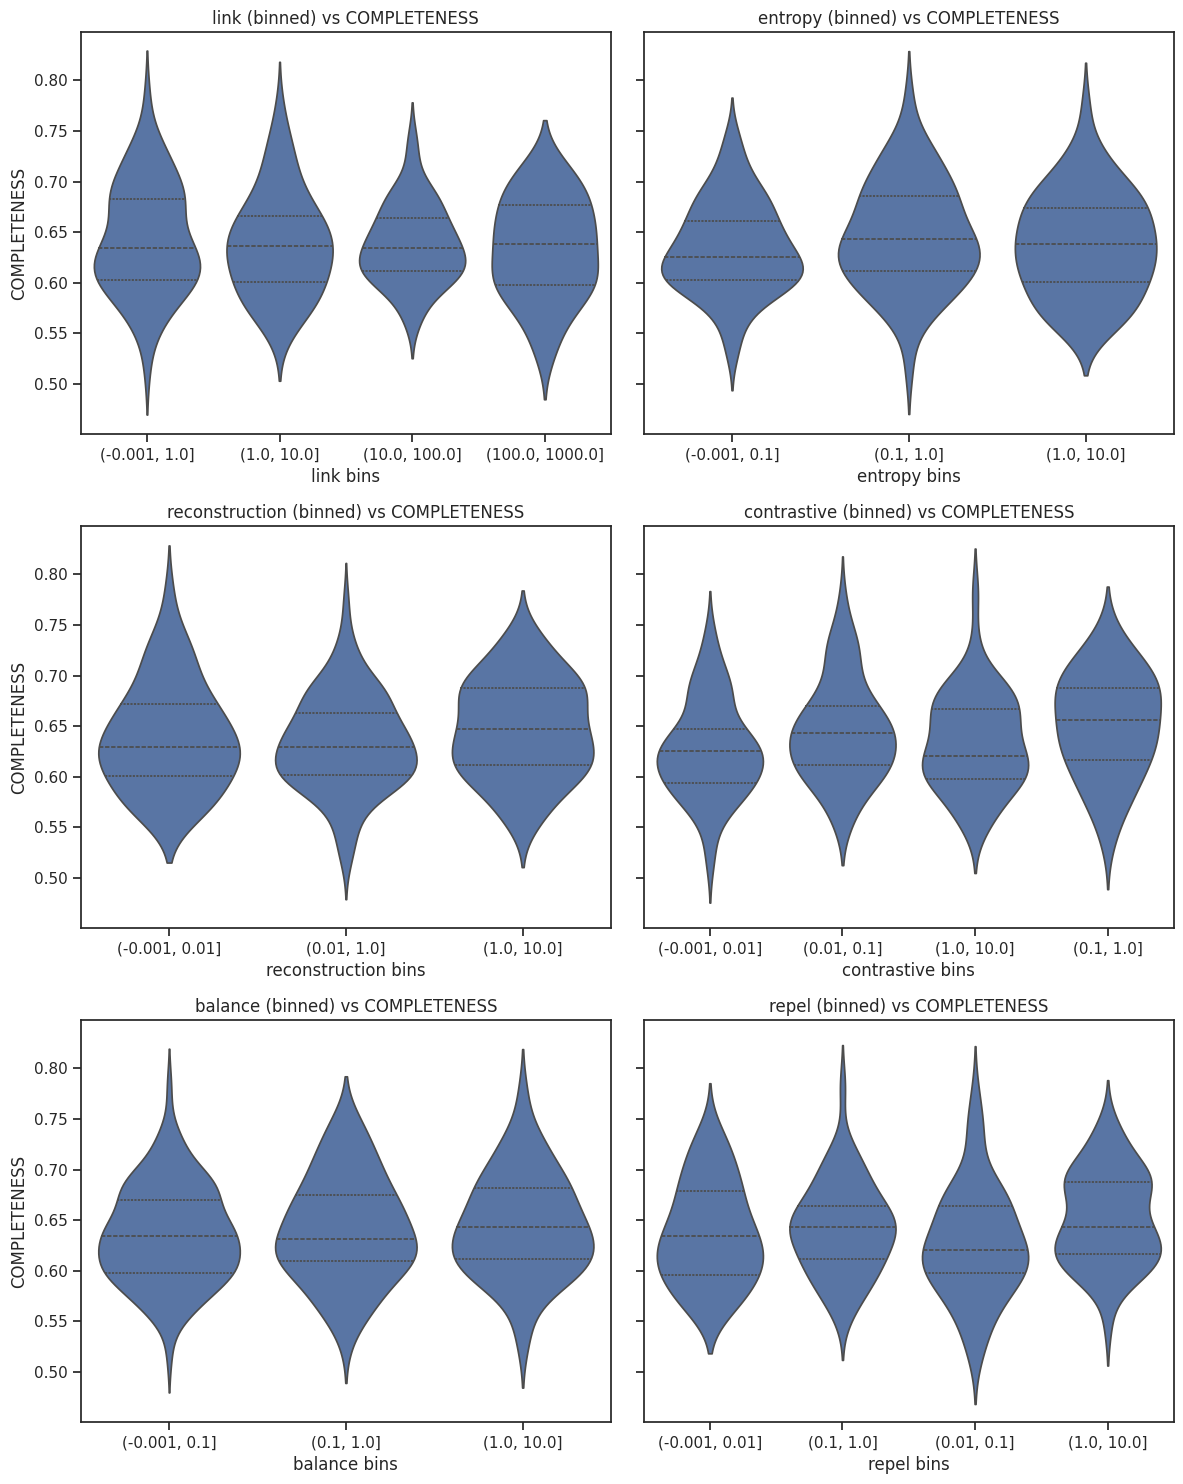

In [12]:
plot_all_violin(df, metric='COMPLETENESS')


In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_hyperparam_heatmap(df, metric='HYBRID_SCORE'):
    hps = ['link','entropy','reconstruction','contrastive','balance','repel']
    pairs = [(h1, h2) for i, h1 in enumerate(hps) for h2 in hps[i+1:]]
    data = {p: df.groupby(list(p))[metric].mean().mean() for p in pairs}
    mat = pd.DataFrame(index=hps, columns=hps, dtype=float)
    for (h1,h2), v in data.items():
        mat.loc[h1,h2] = mat.loc[h2,h1] = v

    mask = mat.isna()
    plt.figure(figsize=(8,8))
    sns.heatmap(mat, mask=mask, cmap='Greys', annot=True, fmt=".4f",
                cbar_kws={'label':metric}, square=True, linewidths=.5, robust=True)
    plt.title(f"{metric} for Hyperparameter Pairs")
    plt.show()


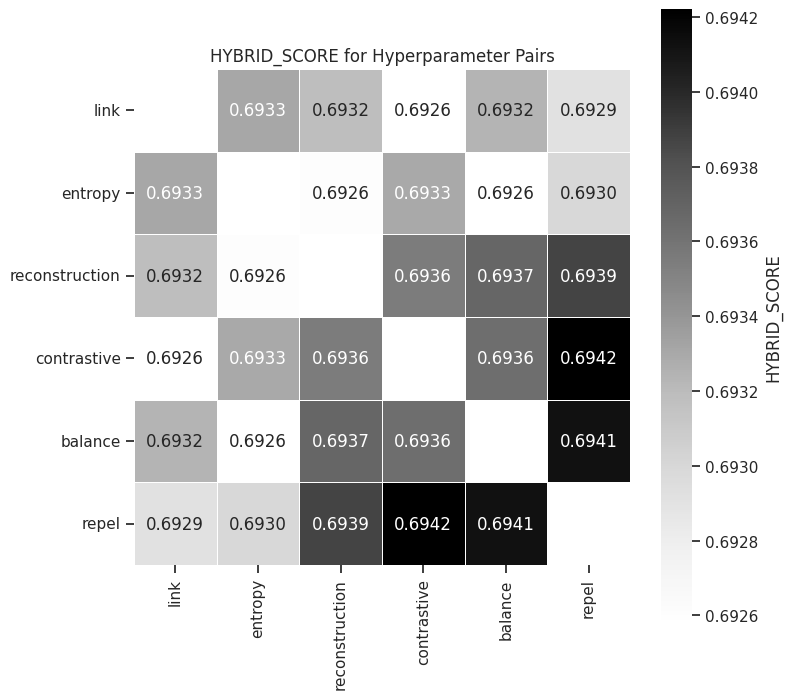

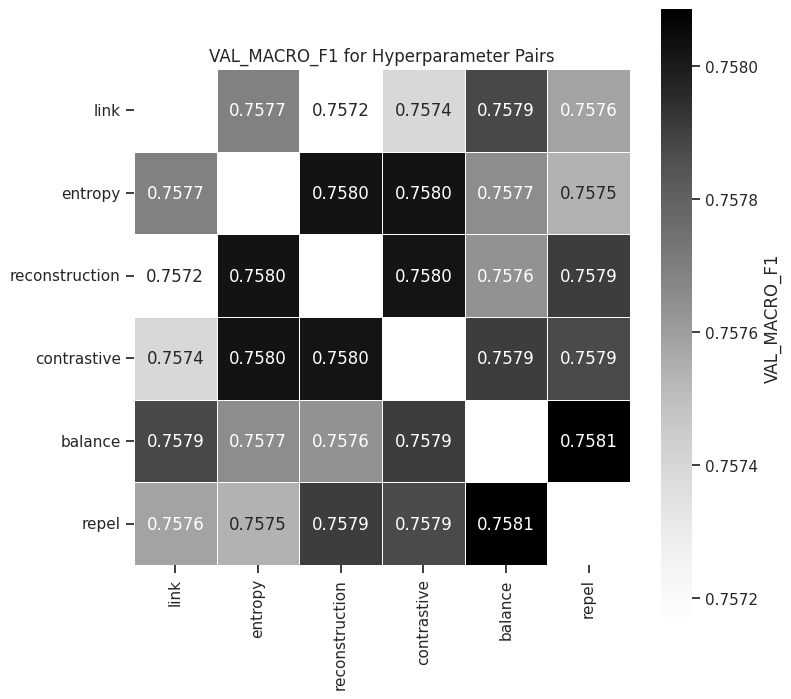

In [23]:
plot_hyperparam_heatmap(df, metric='HYBRID_SCORE')
# or
plot_hyperparam_heatmap(df, metric='VAL_MACRO_F1')

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_all_pairwise_heatmaps(df, metric='HYBRID_SCORE', cmap='Greys'):
    # Identify hyperparameter columns
    hps = ['link','entropy','reconstruction','contrastive','balance','repel']

    # Generate all unordered unique pairs
    from itertools import combinations
    pairs = list(combinations(hps, 2))
    n = len(pairs)
    ncols = 2
    nrows = n // ncols + (n % ncols > 0)

    fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))
    axes = axes.flatten()

    for ax, (h1, h2) in zip(axes, pairs):
        pivot = df.pivot_table(
            index=h2, columns=h1,
            values=metric, aggfunc='mean'
        )
        pivot = pivot.sort_index(ascending=True)
        pivot = pivot.reindex(sorted(pivot.columns), axis=1)

        sns.heatmap(
            pivot,
            cmap=cmap,
            annot=True,
            fmt=".3f",
            ax=ax,
            cbar=ax is axes[0],       # one colorbar only
            cbar_kws={'label': metric},
            robust=True
        )
        ax.set_xlabel(h1)
        ax.set_ylabel(h2)
        ax.set_title(f"{metric}: {h2} vs {h1}")

    # Remove empty subplots if any
    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()


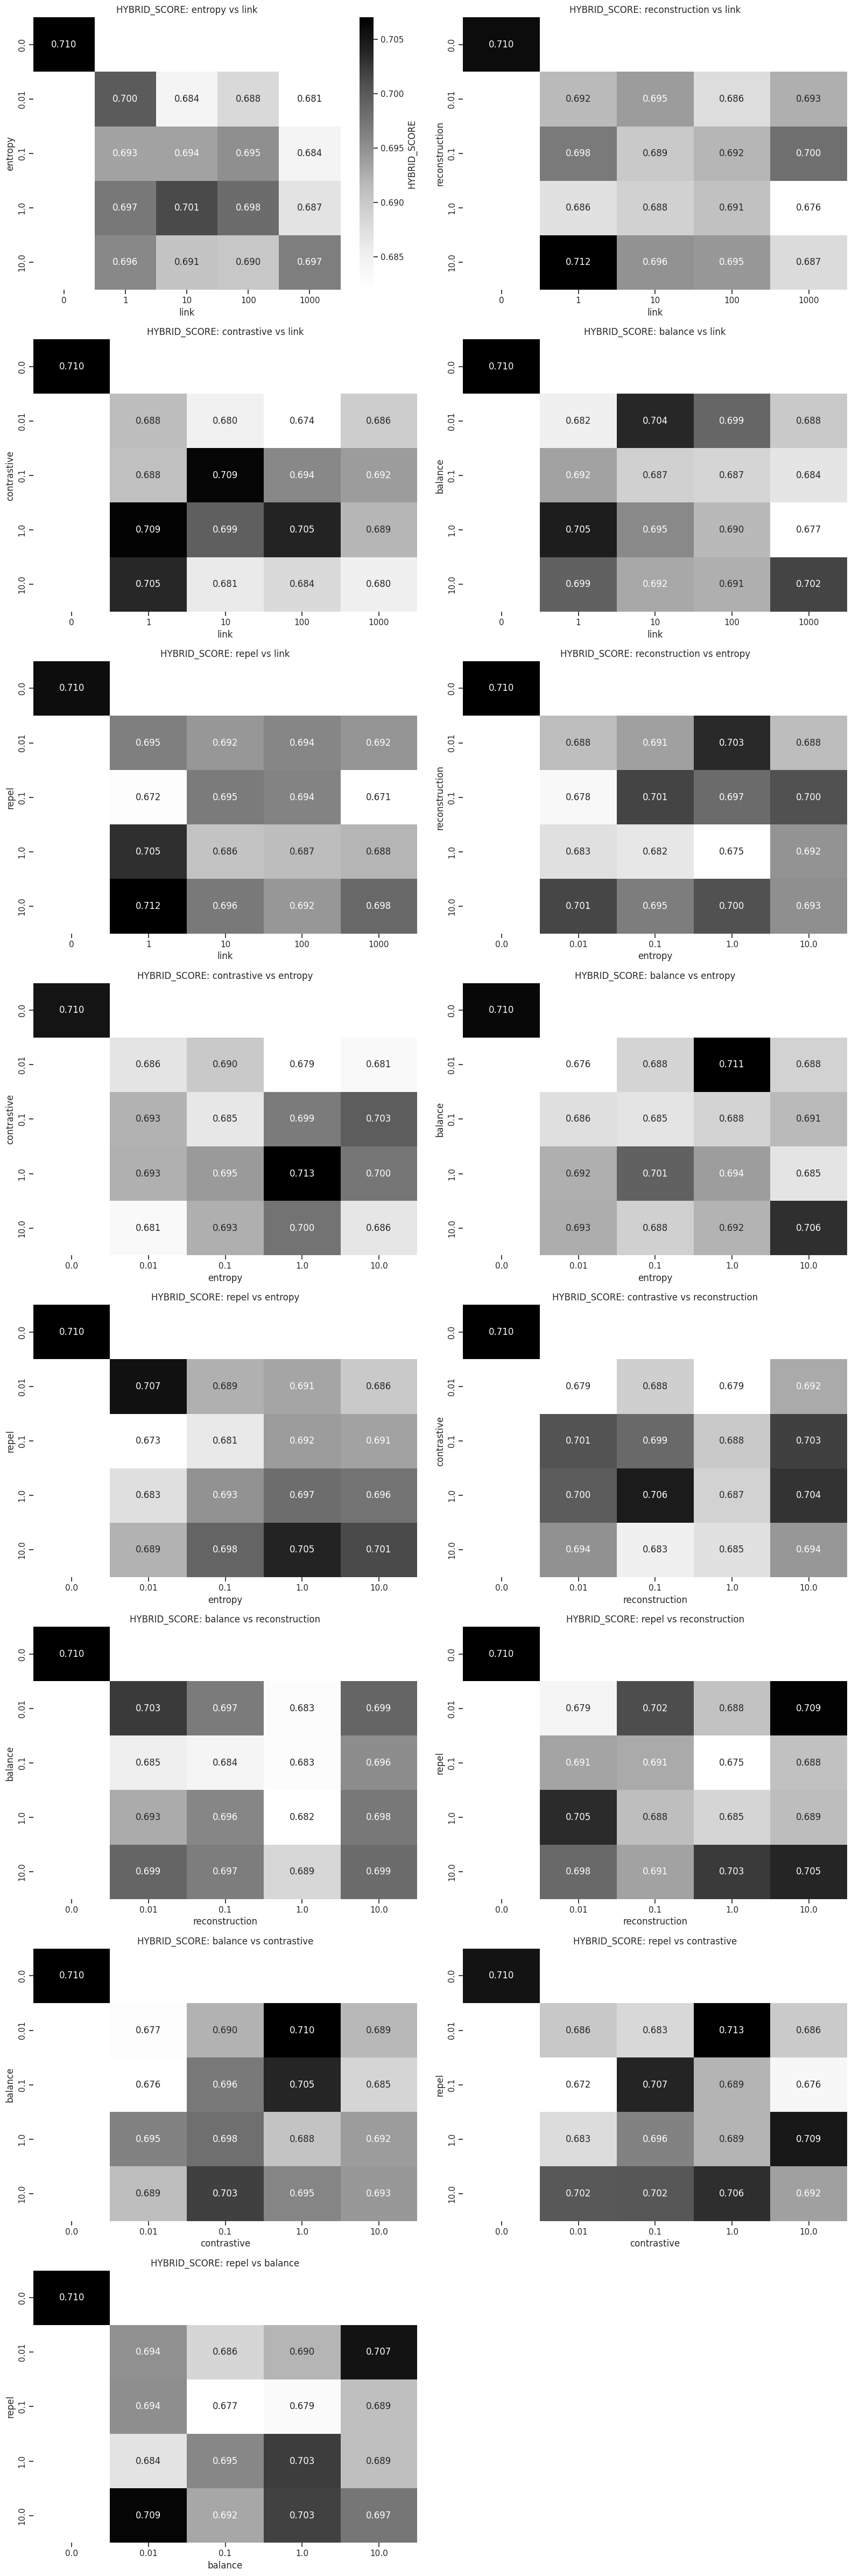

In [29]:
plot_all_pairwise_heatmaps(df,  metric='HYBRID_SCORE')


In [32]:
import pandas as pd

# Assuming 'my_df' is your DataFrame containing the hyperparameters and metrics

# List of metrics to aggregate
metrics = ['HYBRID_SCORE', 'VAL_MACRO_F1', 'COMPLETENESS']

# Initialize an empty dictionary to store the results
result_dict = {}

# Iterate over each hyperparameter column
for hp in ['repel', 'link', 'entropy', 'reconstruction', 'contrastive', 'balance']:
    # Group by the df hyperparameter and calculate the median for each metric
    median_values = df.groupby(hp)[metrics].mean()

    # Store the result in the dictionary
    result_dict[hp] = median_values

# Display the tables for each hyperparameter
for hp, table in result_dict.items():
    print(f"### {hp.capitalize()} Hyperparameter")
    display(table)
    print("\n")


### Repel Hyperparameter


,HYBRID_SCORE,VAL_MACRO_F1,COMPLETENESS
repel,,,
0.00,0.709700,0.743700,0.678600
0.01,0.693198,0.764713,0.635835
0.10,0.684812,0.757796,0.626872
1.00,0.692848,0.755022,0.642050
10.00,0.699260,0.757013,0.651493




### Link Hyperparameter


,HYBRID_SCORE,VAL_MACRO_F1,COMPLETENESS
link,,,
0,0.709700,0.743700,0.678600
1,0.696483,0.762791,0.643014
10,0.692802,0.759821,0.638795
100,0.692155,0.758279,0.637867
1000,0.686488,0.752591,0.633505




### Entropy Hyperparameter


...

,HYBRID_SCORE,VAL_MACRO_F1,COMPLETENESS
reconstruction,,,
0.00,0.709700,0.743700,0.678600
0.01,0.692467,0.759343,0.638809
0.10,0.693723,0.759839,0.640120
1.00,0.684284,0.757209,0.626109
10.00,0.697489,0.758709,0.647168




### Contrastive Hyperparameter


,HYBRID_SCORE,VAL_MACRO_F1,COMPLETENESS
contrastive,,,
0.00,0.709700,0.743700,0.678600
0.01,0.683750,0.756434,0.625957
0.10,0.697427,0.762120,0.644859
1.00,0.700232,0.759362,0.651502
10.00,0.689523,0.757591,0.634598




### Balance Hyperparameter


,HYBRID_SCORE,VAL_MACRO_F1,COMPLETENESS
balance,,,
0.00,0.709700,0.743700,0.678600
0.01,0.693660,0.757848,0.641157
0.10,0.687976,0.759734,0.630671
1.00,0.693392,0.758300,0.640971
10.00,0.695689,0.759033,0.644124


In [34]:
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr

# Assuming 'my_df' is your DataFrame containing hyperparameters and metrics
metrics = ['HYBRID_SCORE', 'VAL_MACRO_F1', 'COMPLETENESS']
hyperparameters = ['link', 'entropy', 'reconstruction', 'contrastive', 'balance', 'repel']

# Initialize an empty dictionary to store results
correlation_results = {}

# Iterate over each hyperparameter
for hp in hyperparameters:
    # Create a table to store correlations for the current hyperparameter
    correlation_table = pd.DataFrame(columns=metrics, index=df[hp].unique())

    # Iterate over each metric
    for metric in metrics:
        # For each unique value of the hyperparameter
        for value in df[hp].unique():
            # Create a binary indicator for the current value
            binary_indicator = (df[hp] == value).astype(int)

            # Calculate the point-biserial correlation
            corr, _ = pointbiserialr(binary_indicator, df[metric])

            # Store the result in the table
            correlation_table.loc[value, metric] = round(corr,3)

    # Store the correlation table for the current hyperparameter
    correlation_results[hp] = correlation_table

# Display the correlation tables
for hp, table in correlation_results.items():
    print(f"Correlation between {hp} and metrics:")
    display(table)
    print("\n")


Correlation between link and metrics:


,HYBRID_SCORE,VAL_MACRO_F1,COMPLETENESS
0,0.042,-0.054,0.057
1,0.088,0.132,0.054
10,0.007,0.035,-0.001
100,-0.005,-0.012,-0.011
1000,-0.107,-0.164,-0.057




Correlation between entropy and metrics:


,HYBRID_SCORE,VAL_MACRO_F1,COMPLETENESS
0.00,0.042,-0.054,0.057
0.01,-0.074,-0.0,-0.074
0.10,-0.022,0.008,-0.03
1.00,0.074,-0.061,0.097
10.00,0.008,0.062,-0.009




Correlation between reconstruction and metrics:


...

,HYBRID_SCORE,VAL_MACRO_F1,COMPLETENESS
0.00,0.042,-0.054,0.057
0.01,-0.186,-0.073,-0.164
0.10,0.097,0.099,0.069
10.00,-0.056,-0.032,-0.048
1.00,0.148,0.018,0.142




Correlation between balance and metrics:


,HYBRID_SCORE,VAL_MACRO_F1,COMPLETENESS
0.00,0.042,-0.054,0.057
0.10,-0.099,0.033,-0.108
1.00,0.019,-0.013,0.025
10.00,0.06,0.009,0.058
0.01,0.021,-0.023,0.024




Correlation between repel and metrics:


,HYBRID_SCORE,VAL_MACRO_F1,COMPLETENESS
0.00,0.042,-0.054,0.057
0.01,0.015,0.186,-0.038
1.00,0.008,-0.109,0.037
0.10,-0.151,-0.027,-0.141
10.00,0.125,-0.047,0.138


In [38]:
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr

# Assuming 'my_df' is your DataFrame containing hyperparameters and metrics
metrics = ['HYBRID_SCORE', 'VAL_MACRO_F1', 'COMPLETENESS']
hyperparameters = ['link', 'entropy', 'reconstruction', 'contrastive', 'balance', 'repel']

# Initialize an empty DataFrame to store the correlation results
correlation_results = pd.DataFrame(index=hyperparameters, columns=metrics)

# Iterate over each hyperparameter
for hp in hyperparameters:
    for metric in metrics:
        # Create binary indicators for each unique value of the hyperparameter
        for value in df[hp].unique():
            binary_hp = (df[hp] == value).astype(int)
            # Calculate the point-biserial correlation
            corr, _ = pointbiserialr(binary_hp, df[metric])
            # Store the correlation in the DataFrame
            correlation_results.loc[hp, metric] = round(corr,3)

# Display the correlation results
display(correlation_results)


,HYBRID_SCORE,VAL_MACRO_F1,COMPLETENESS
link,-0.107,-0.164,-0.057
entropy,0.008,0.062,-0.009
reconstruction,0.109,-0.0,0.106
contrastive,0.148,0.018,0.142
balance,0.021,-0.023,0.024
repel,0.125,-0.047,0.138


# Statistical test

In [39]:
from scipy.stats import kruskal

results = []

for hp in ["link", "entropy", "reconstruction", "contrastive", "balance", "repel"]:
    for metric in ["HYBRID_SCORE", "VAL_MACRO_F1", "COMPLETENESS"]:
        groups = [group[metric].values for _, group in df.groupby(hp)]
        if len(groups) >= 2:
            stat, p = kruskal(*groups)
            results.append((hp, metric, stat, p))

df_stats = pd.DataFrame(results, columns = ["Hyperparameter", "Metric", "Statistic", "P-value"])
display(df_stats)

,Hyperparameter,Metric,Statistic,P-value
0,link,HYBRID_SCORE,2.532476,0.638830
1,link,VAL_MACRO_F1,4.990997,0.288223
2,link,COMPLETENESS,1.301945,0.861045
3,entropy,HYBRID_SCORE,2.292417,0.682150
4,entropy,VAL_MACRO_F1,1.644937,0.800694
5,entropy,COMPLETENESS,2.959399,0.564643
6,reconstruction,HYBRID_SCORE,5.722108,0.220885
7,reconstruction,VAL_MACRO_F1,2.157454,0.706826
8,reconstruction,COMPLETENESS,5.487222,0.240855
9,contrastive,HYBRID_SCORE,10.112492,0.038575


In [40]:
from scipy.stats import spearmanr

correlation_results = []

for hp in ["link", "entropy", "reconstruction", "contrastive", "balance", "repel"]:
    for metric in ["HYBRID_SCORE", "VAL_MACRO_F1", "COMPLETENESS"]:
        corr, p = spearmanr(df[hp], df[metric])
        correlation_results.append((hp, metric, corr, p))

df_stats = pd.DataFrame(correlation_results, columns = ["Hyperparameter", "Metric", "Statistic", "P-value"])
display(df_stats)

,Hyperparameter,Metric,Statistic,P-value
0,link,HYBRID_SCORE,-0.094266,0.184268
1,link,VAL_MACRO_F1,-0.110313,0.119939
2,link,COMPLETENESS,-0.053274,0.453722
3,entropy,HYBRID_SCORE,0.050157,0.480612
4,entropy,VAL_MACRO_F1,0.040892,0.565349
5,entropy,COMPLETENESS,0.045088,0.526107
6,reconstruction,HYBRID_SCORE,0.044307,0.533297
7,reconstruction,VAL_MACRO_F1,-0.038875,0.584695
8,reconstruction,COMPLETENESS,0.048201,0.497909
9,contrastive,HYBRID_SCORE,0.084645,0.233378


In [43]:
from scipy.stats import kruskal
import pandas as pd

hyperparams = ["link", "entropy", "reconstruction", "contrastive", "balance", "repel"]
metrics = ["HYBRID_SCORE", "VAL_MACRO_F1", "COMPLETENESS"]

kruskal_results = []

for hp in hyperparams:
    for metric in metrics:
        groups = [group[metric].values for _, group in df.groupby(hp)]
        if len(groups) >= 2:
            stat, p = kruskal(*groups)
            kruskal_results.append({
                "Hyperparameter": hp,
                "Metric": metric,
                "Kruskal_statistic": stat,
                "p-value": p,
                "Significant": p < 0.1
            })

# Display results as a DataFrame
kruskal_df = pd.DataFrame(kruskal_results)
display(kruskal_df.sort_values(by="p-value"))


,Hyperparameter,Metric,Kruskal_statistic,p-value,Significant
9,contrastive,HYBRID_SCORE,10.112492,0.038575,True
11,contrastive,COMPLETENESS,9.437172,0.051054,True
16,repel,VAL_MACRO_F1,8.124044,0.087139,True
17,repel,COMPLETENESS,7.929449,0.094197,True
15,repel,HYBRID_SCORE,6.871512,0.142836,False
6,reconstruction,HYBRID_SCORE,5.722108,0.220885,False
8,reconstruction,COMPLETENESS,5.487222,0.240855,False
1,link,VAL_MACRO_F1,4.990997,0.288223,False
14,balance,COMPLETENESS,3.068106,0.546493,False
5,entropy,COMPLETENESS,2.959399,0.564643,False


In [42]:
from scipy.stats import spearmanr

spearman_results = []

for hp in ["link", "entropy", "reconstruction", "contrastive", "balance", "repel"]:
    for metric in metrics:
        corr, p = spearmanr(df[hp], df[metric])
        spearman_results.append({
            "Hyperparameter": hp,
            "Metric": metric,
            "Spearman_corr": corr,
            "p-value": p,
            "Significant": p < 0.1
        })

spearman_df = pd.DataFrame(spearman_results)
display(spearman_df.sort_values(by="p-value"))


,Hyperparameter,Metric,Spearman_corr,p-value,Significant
16,repel,VAL_MACRO_F1,-0.144489,0.041221,True
17,repel,COMPLETENESS,0.139532,0.048773,True
1,link,VAL_MACRO_F1,-0.110313,0.119939,False
15,repel,HYBRID_SCORE,0.098185,0.166609,False
0,link,HYBRID_SCORE,-0.094266,0.184268,False
9,contrastive,HYBRID_SCORE,0.084645,0.233378,False
11,contrastive,COMPLETENESS,0.082812,0.243696,False
2,link,COMPLETENESS,-0.053274,0.453722,False
3,entropy,HYBRID_SCORE,0.050157,0.480612,False
8,reconstruction,COMPLETENESS,0.048201,0.497909,False


In [6]:
from sklearn.linear_model import HuberRegressor
import pandas as pd

# Features and targets
X = df[["link", "entropy", "reconstruction", "contrastive", "balance", "repel"]]
targets = ["HYBRID_SCORE", "VAL_MACRO_F1", "COMPLETENESS"]

coeff_table = []

for target in targets:
    y = df[target]
    model = HuberRegressor().fit(X, y)
    for feat, coef in zip(X.columns, model.coef_):
        coeff_table.append({
            "Metric": target,
            "Hyperparameter": feat,
            "Coefficient": coef
        })

# Display as DataFrame
coeff_df = pd.DataFrame(coeff_table)
pivot = coeff_df.pivot(index="Hyperparameter", columns="Metric", values="Coefficient")
display(pivot.round(4))


Metric,COMPLETENESS,HYBRID_SCORE,VAL_MACRO_F1
Hyperparameter,,,
balance,0.0007,0.0004,0.0000
contrastive,-0.0006,-0.0004,-0.0002
entropy,0.0004,0.0002,0.0000
link,-0.0000,-0.0000,-0.0000
reconstruction,0.0014,0.0010,-0.0001
repel,0.0019,0.0010,-0.0004
